In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

'/Users/smin/IdeaProjects/crop-yield-prediction/notebooks'

Kaggle Agriculture Crop Yield (합성 데이터, 100만 행)
농경지 환경/관리 조건 + 그때의 수확량

" 어떠한 환경에서 어떤 작물을 키웠는데 1헥타르당 수확량이 몇 톤 나왔다.. " 
-> 우리는 어떠한 환경과 수확량의 모종의 관계를 상관계수 분석을 통해 분석하고 회귀예측을 통해 수확량의 연속적인 값을 예측한다. 모델은 랜덤포레스트회귀 를 베이스라인으로 두고 평가지표는 MAE, RMSE 를 사용한다.

먼저 랜덤포레스트회귀 와 평가지표를 이것으로 둔 이유는 

작물 수확량은 환경 변수와 비선형 관계일 가능성이 높다. -> 왜 가능성 높음?
-> 식물 생장 변수에는 최적점이 있다 식물 마다는 다르겠지만 강수량, 기온, 일조량 등 각 환경변수에 대한
최적의 조건 값이 있다 너무 적거나 너무 많거나 가 좋은 값이 아닌 평균적인 값의 구간이 있으므로
선형적인 관계는 비현실적인 결론으로 내딛어진다. 따라서 자연현상은 임계점과 포화가 흔하다
→ 농학에서 잘 알려진 패턴: Liebig의 최소량 법칙, 종 모양 반응 곡선 (Claude)

선형 회귀는 직선 관계만 잡지만 RF는 곡선 / 임계 패턴도 자동으로 처리 -> 어떻게 처리하는지?
-> 임계값 자체가 비선형 처리의 핵심이다. 임계값들의 조합으로 계단 함수를 만들고 트리 100개 평균(RF)
  -> 부드러운 곡선을 근사한다.
    -> 곡선을 직선 조각 수백 개로 나누어서 그린다고 생각하면 됨 ( 적분 )
    
선형 회귀는 정규성/등분산성/독립성 등 가정 검증해야하지만 RF는 비모수 모델이라 가정이 존재하지 않는다 -> 비모수 모델은 뭐고 가정은 왜 존재하지 않음?
-> 모수(Parametric) : 데이터가 특정 분포 또는 관계를 따른다고 가정 그리고 그 파라미터를 추정
  -> 선형 회귀(직선 관계 가정), 로지스틱 회귀, t-test
    -> 정규성 , 등분산성, 독립성, 선형성
-> 비모수(non-parametric) : 사전 가정 없이 데이터 자체에서 패턴 학습
  -> RF, KNN, 결정 트리
    -> 분포 가정은 사실상 없다.
선형회귀는 "Y = β₀ + β₁X + ε, ε ~ N(0,σ²)" 식으로 확률 분포 가정이 박혀있다. RF 는 그냥 데이터 보고 임계값 찾자 이므로 가정 자체가 존재할 수 없다.

트리기반이라 극단값에 덜 끌려간다. -> 왜 트리기반인지? 그리고 트리기반은 왜 극단값에 덜 끌려가나?
-> 랜덤 포레스트의 정의는 여러 결정 트리의 앙상블(평균) 이름 그대로 랜덤한 트리들의 숲 트리가 RF의 기본 단위
 -> 트리 분기 기준으로 값이 임계값보다 큰가 / 작은가 는 값이 100 이던 1000이던 같은 분기 그룹으로 들어간다.
 하지만 선형 회귀는 제곱합(SSE) 최소화 -> 큰 값이 회귀선을 강하게 끌어당긴다.
 트리는 정렬 후 분기점만 찾아서 그룹을 나누기 때문에 절대값 크기 영향이 거의 존재하지 않음 ㅇㅇ

예를 들어 키로 줄을 세운다하면 1등이 180 이든 250이든 1등은 1등임, 평균은 250 이 끼면 평균이 올라가지만 키 큰 그룹 작은 그룹을 나누는데에는 영향이 거의 없음

표준화/정규화 안 해도 잘 동작 -> 왜?

표준화와 정규화가 필요한 모델은 거리기반(KNN, K-means), 그레디언트 기반(SVM, 신경망), 정규화 회귀(Ridge, Lasso). 이런 모델들은 스케일 큰 피처가 손실함수와 거리를 지배함

벗. 트리는 분기점만 찾으면 된다. -> 강수량 > 500 분기 결과와 표준화된 강수량 > 0.5 의 분기 결과는 완전히 동일 분기는 순서만 보고 크기는 안본다. 그래서 스케일 중요하지 않음 ㅇㅇ


평가지표를 MAE + RMSE 를 사용한 이유는

MAE (평균 절대 오차) -> 예측과 실제 차이 절대값의 평균
-> 종속 변수와 같은 단위 -> 평균 0.5톤 오차 식으로 직관적 해석이 가능하다

RMSE (평균 제곱근 오차) -> 차이 제곱 평균의 루트 -> 큰 오차에 패널티를 더 부과한다. -> 회귀의 표준 지표

MAE 는 평균적 오차 크기는 알지만 큰 오차(이상치)가 있는지는 알 수 없다.
RMSE 는 큰 오차에는 민감하지만 평균적인 오차에 대해서는 직관력이 떨어진다.

R^2은 왜 안씀? -> 가능하긴 한데 분산의 X% 설명은 이해하기 어려움 -> 만약 의사결정에 R^2 을 쓴다면 
MAE, RMSE 보다 해석력이 비슷하거나 직관적이어야 하는데 그렇지 못함 R^2 0.85 이해하기 쉬움? 
-> R² 0.85 의미 = "종속변수 분산의 85%를 모델이 설명함" -> 일반인이 분산 알아? 설명 알아?
MAE 0.5톤 의미 = "평균 0.5톤 빗나감" -> 직관적 농부도 이해한다

In [15]:
df = pd.read_csv("../data/crop_yield.csv")
df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [16]:
df.shape

(1000000, 10)

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Region                  1000000 non-null  str    
 1   Soil_Type               1000000 non-null  str    
 2   Crop                    1000000 non-null  str    
 3   Rainfall_mm             1000000 non-null  float64
 4   Temperature_Celsius     1000000 non-null  float64
 5   Fertilizer_Used         1000000 non-null  bool   
 6   Irrigation_Used         1000000 non-null  bool   
 7   Weather_Condition       1000000 non-null  str    
 8   Days_to_Harvest         1000000 non-null  int64  
 9   Yield_tons_per_hectare  1000000 non-null  float64
dtypes: bool(2), float64(3), int64(1), str(4)
memory usage: 62.9 MB


In [18]:
df.describe()

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372


In [19]:
df.isnull().sum()

Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64

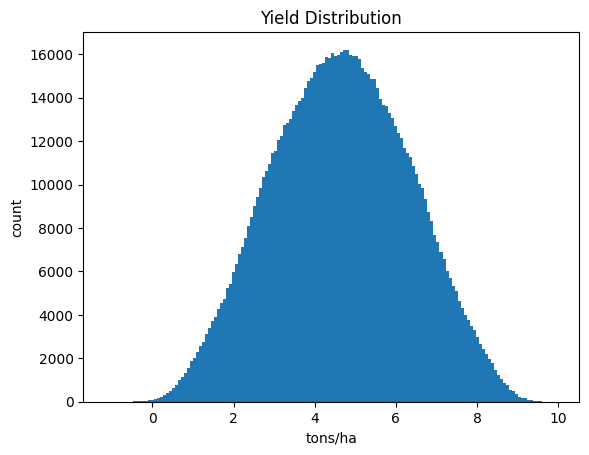

In [27]:
#그래서 왜 종속변수만 히스토그램을 쓰는지? 
# -> 타겟 분포가 곧 문제 정의 -> 모델이 맞춰야 하는 값 -> 문제가 얼마나 어려운가를 보여줌
# 타겟 분포가 뭔데?
# 타겟 분포를 보고 정상적인 예측값의 범위가 어느정도로 나오는지 볼 수 있음
# 또한 평가지표 해석에 직접적으로 다가갈 수 있음 
# 모델 / 전처리 선택에 영향
# 정규분포는 그대로 회귀해도 좋음 / 오른쪽으로 쏠림은 로그 변환 고려 / 
# 이중 분포는 두 집단이 섞여 있다는 신호로 분리해야할 수있음
plt.hist(df['Yield_tons_per_hectare'], bins=150)
plt.title('Yield Distribution')
plt.xlabel('tons/ha')
plt.ylabel('count')
plt.show()

In [29]:
# 1. 수치형 컬럼만 골라서 상관행렬 계산
numeric_cols = ['Rainfall_mm', 'Temperature_Celsius', 'Days_to_Harvest', 'Yield_tons_per_hectare']
corr = df[numeric_cols].corr()


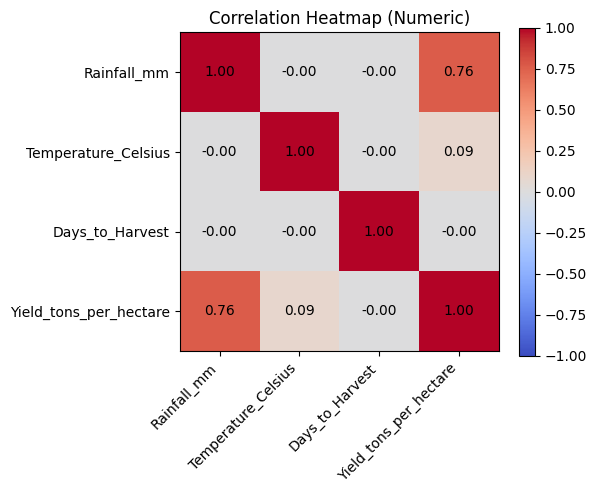

In [31]:
# 2. 히트맵 그리기
plt.figure(figsize=(6, 5))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()

# 3. 축 라벨 (컬럼명 표시)
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha='right')
plt.yticks(range(len(numeric_cols)), numeric_cols)

# 4. 셀 안에 숫자 표시 (annotation)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center')

plt.title('Correlation Heatmap (Numeric)')
plt.tight_layout()
plt.show()

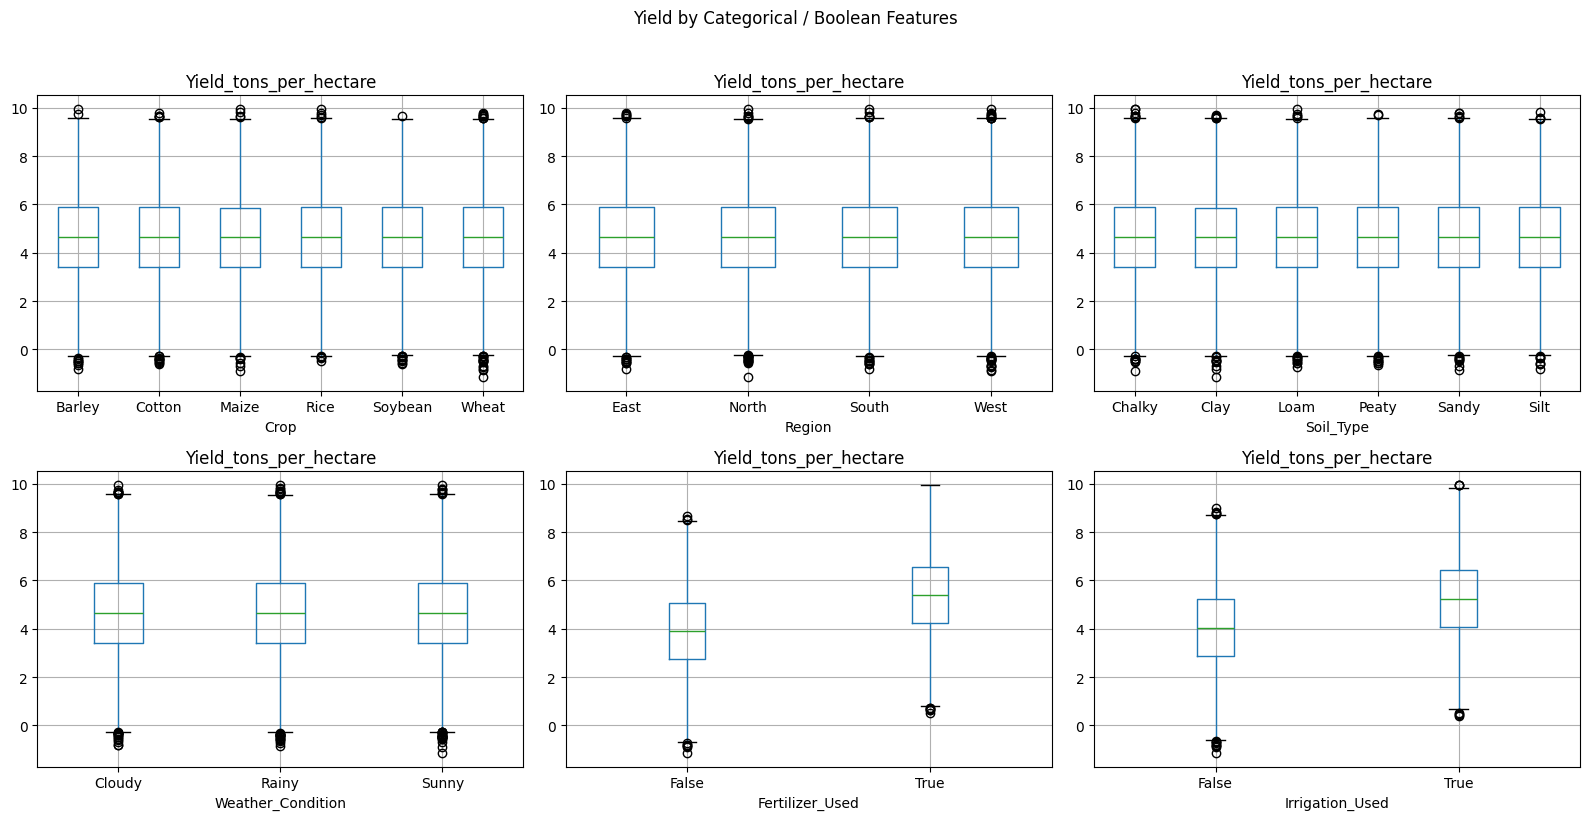

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# 범주형 4개
df.boxplot(column='Yield_tons_per_hectare', by='Crop',              ax=axes[0, 0])
df.boxplot(column='Yield_tons_per_hectare', by='Region',            ax=axes[0, 1])
df.boxplot(column='Yield_tons_per_hectare', by='Soil_Type',         ax=axes[0, 2])
df.boxplot(column='Yield_tons_per_hectare', by='Weather_Condition', ax=axes[1, 0])

# 불리언 2개
df.boxplot(column='Yield_tons_per_hectare', by='Fertilizer_Used',   ax=axes[1, 1])
df.boxplot(column='Yield_tons_per_hectare', by='Irrigation_Used',   ax=axes[1, 2])

plt.suptitle('Yield by Categorical / Boolean Features', y=1.02)
plt.tight_layout()
plt.show()

같은 피처에서 그룹 간:
- 박스/중앙값 위치가 비슷  →  그룹별 차이 없음  →  예측에 무용
- 박스/중앙값 위치가 다름  →  그룹별 차이 있음  →  예측에 유용

판단은 중앙값을 비교하는거임

위 플롯들을 보면 상단 패널들은 각 박스의 중앙값이 전부 다 같기 때문에 수확량이 작물 종류, 지역, 토양에 무관한 것을 알 수 있음

하단 을 보면 날씨 조건 까지는 중앙값이 같기에 무관하고 

Fertilizer_Used, Irrigation_Used 의 중앙값이 다른 것을 알 수 있으므로 예측에 유용한 것을 알 수 있음

EDA 는 이정도로 끝 따라서 수확량에 대한 좋은 피쳐는 플롯에서 Fertilizer_Used, Irrigation_Used 2개
히트맵에서 Rain_Fall 1개 

하지만 RF 학습 후 .feature_importances_로 다시 검증해야함 비선형/상호작용 효과는 시각화에서 알 수 없으므로

In [38]:
# 1. X / y 분리
y = df['Yield_tons_per_hectare']
X = df.drop(columns=['Yield_tons_per_hectare'])

# 2. 범주형 4개 → 원핫 인코딩
X = pd.get_dummies(X, columns=['Crop', 'Region', 'Soil_Type', 'Weather_Condition'], dtype=int)

# 3. 불리언 → int (True/False → 1/0)
X['Fertilizer_Used'] = X['Fertilizer_Used'].astype(int)
X['Irrigation_Used'] = X['Irrigation_Used'].astype(int)

# 4. 결과 확인
print(X.shape, y.shape)
X.head()
X.dtypes   # 전부 int/float여야 함

(1000000, 24) (1000000,)


Rainfall_mm                 float64
Temperature_Celsius         float64
Fertilizer_Used               int64
Irrigation_Used               int64
Days_to_Harvest               int64
Crop_Barley                   int64
Crop_Cotton                   int64
Crop_Maize                    int64
Crop_Rice                     int64
Crop_Soybean                  int64
Crop_Wheat                    int64
Region_East                   int64
Region_North                  int64
Region_South                  int64
Region_West                   int64
Soil_Type_Chalky              int64
Soil_Type_Clay                int64
Soil_Type_Loam                int64
Soil_Type_Peaty               int64
Soil_Type_Sandy               int64
Soil_Type_Silt                int64
Weather_Condition_Cloudy      int64
Weather_Condition_Rainy       int64
Weather_Condition_Sunny       int64
dtype: object

원핫 인코딩 -> 범주형 컬럼을 0/1 이진 컬럼들로 분해함

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(800000, 24) (200000, 24)
(800000,) (200000,)


test_size=0.2 -> 20%를 테스트셋으로 (80% 학습 / 20% 평가)
random_state=42 -> 셔플 시드. 재현성 위해 고정. 숫자 자체는 의미 없음

In [42]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [43]:
# 테스트셋에 대한 예측
y_pred = model.predict(X_test)

# 평가 지표
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'MAE:  {mae:.4f} tons/ha')
print(f'RMSE: {rmse:.4f} tons/ha')

MAE:  0.4115 tons/ha
RMSE: 0.5157 tons/ha


RandomForest 베이스라인 학습 결과: MAE 0.41 ton/ha, RMSE 0.52 ton/ha.
RMSE/MAE 비율 1.25 → 오차 균등 분포, 큰 이상치 영향 적음.
"타겟 평균 예측" 단순 베이스라인(MAE ~1.6) 대비 약 75% 개선.

테스트셋 MAE 0.41 ton/ha. 평균 예측 베이스라인(1.6)대비 75% 개선. RMSE/MAE 비율 1.25로 오차가 균등 분포 → 일부 케이스에서 크게 빗나가는 패턴 없이 안정적인 예측 수행

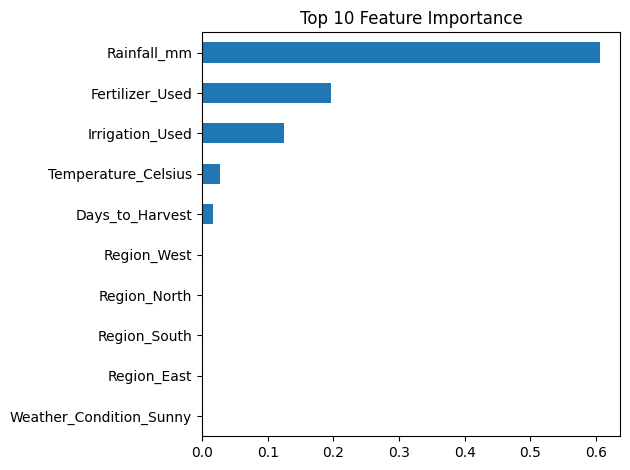

In [45]:
fi.head(10).plot.barh()
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importance')
plt.tight_layout()
plt.show()

Rainfall(60.6%) + Fertilizer(19.6%) + Irrigation(12.5%) = 92.7%로 모델 결정의 대부분 설명.
선형상관 약했던 Temperature·Days_to_Harvest도 ~3%, ~2%의 비선형 신호 — 피처 자르지 않고 RF에 맡긴 결정이 적중.
범주형(Crop·Region·Soil_Type·Weather)은 각 ~0.16%로 사실상 무용 → EDA 결론과 일치.

선형 상관이 약한 Temperature, Days_to_Harvest도 RF feature importance에선 ~3%, ~2% 신호를 보여줌. 사람이 EDA에서 '필요 없어 보인다'고 자르지 않고 RF에 맡긴 결과 비선형 효과까지 활용

In [46]:
import os
os.makedirs('../models', exist_ok=True)

In [ ]:
from skl2onnx import to_onnx

# 입력 샘플 (shape/dtype 추론용) — float32로 변환
initial_input = X_train.iloc[:1].astype(np.float32).values

# sklearn → ONNX 변환
onnx_model = to_onnx(model, initial_input, target_opset=15)

# 파일로 저장
with open('../models/crop_yield_rf.onnx', 'wb') as f:
    f.write(onnx_model.SerializeToString())

print('ONNX 저장 완료:', '../models/crop_yield_rf.onnx')

기본 RF는 `max_depth=None`으로 트리가 끝까지 자라 ONNX 변환 시 그래프가 거대화 → 배포 불가능
`max_depth=20`, `min_samples_leaf=20` 제약 추가 후 정확도/크기/변환 시간 비교.


In [49]:
model_deploy = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,        # 깊이 제한
    min_samples_leaf=20, # 잎 최소 샘플
    random_state=42,
    n_jobs=-1
)
model_deploy.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [50]:
# 제약 모델 평가
y_pred_deploy = model_deploy.predict(X_test)
mae_deploy = mean_absolute_error(y_test, y_pred_deploy)
rmse_deploy = np.sqrt(mean_squared_error(y_test, y_pred_deploy))

# 비교 출력
print('--- 모델 비교 ---')
print(f'기존 (default, max_depth=None): MAE {mae:.4f}, RMSE {rmse:.4f}')
print(f'제약 (max_depth=20):            MAE {mae_deploy:.4f}, RMSE {rmse_deploy:.4f}')
print(f'MAE 차이: {(mae_deploy - mae):+.4f}')

--- 모델 비교 ---
기존 (default, max_depth=None): MAE 0.4115, RMSE 0.5157
제약 (max_depth=20):            MAE 0.4031, RMSE 0.5052
MAE 차이: -0.0083


초기 default RF는 max_depth=None으로 학습 → ONNX 변환 시 모델이 너무 커져 배포 불가능 판단. max_depth=20, min_samples_leaf=20 제약 추가.
결과: 정확도 손실 우려와 달리 MAE 0.4115 → 0.4031로 오히려 향상. 트리 정규화로 과적합 완화된 효과로 추정. 배포 가능성 + 일반화 성능 둘 다 얻음

In [51]:
initial_input = X_train.iloc[:1].astype(np.float32).values
onnx_model = to_onnx(model_deploy, initial_input, target_opset=15)

with open('../models/crop_yield_rf.onnx', 'wb') as f:
    f.write(onnx_model.SerializeToString())

In [53]:
import onnxruntime as ort

sess = ort.InferenceSession('../models/crop_yield_rf.onnx')
input_name = sess.get_inputs()[0].name

# 테스트셋 첫 5개로 ONNX 추론
test_input = X_test.iloc[:5].astype(np.float32).values
onnx_pred = sess.run(None, {input_name: test_input})[0].flatten()

# sklearn 예측과 비교
sklearn_pred = model.predict(X_test.iloc[:5])

print('ONNX   :', onnx_pred)
print('sklearn:', sklearn_pred)
print('최대 오차:', np.abs(onnx_pred - sklearn_pred).max())

ONNX   : [4.0657487 4.7484474 7.1875334 2.6281705 4.189108 ]
sklearn: [4.13016662 4.71788692 7.11057948 2.64838281 4.20234795]
최대 오차: 0.07695389395503494


초기 default RF는 max_depth=None으로 학습 → ONNX 변환 시 모델이 너무 커져 배포 불가능 판단. max_depth=20, min_samples_leaf=20 제약 추가.
결과: 정확도 손실 우려와 달리 MAE 0.4115 → 0.4031로 오히려 향상. 트리 정규화로 과적합 완화된 효과로 추정. 배포 가능성 + 일반화 성능 둘 다 얻음

0.077 최대 오차 -> float32 정밀도 한계 

트리 분기 임계값은 학습 시 float64로 결정 (예: Rainfall > 523.4567891)
ONNX 변환 시 float32로 캐스팅 → 523.4567 정도로 반올림
임계값 근처 샘플은 분기 방향이 달라질 수 있음
100개 트리 중 1~2개에서 다른 잎으로 가면 → 평균 예측값이 ~0.07 변동

ONNX float32 변환 시 트리 임계값 반올림으로 sklearn 대비 최대 ~0.08 ton/ha 오차 관찰
모델 자체 MAE(0.40)의 20% 수준이라 배포 허용 가능 판단
더 엄격히 하려면 DoubleTensorType 사용해 float64 입력 ONNX로 변환 가능, 단 모델 크기 증가 트레이드오프

In [56]:
from skl2onnx.common.data_types import DoubleTensorType

initial_type = [('float_input', DoubleTensorType([None, X_train.shape[1]]))]
onnx_model_f64 = to_onnx(model_deploy, initial_types=initial_type, target_opset=15)

with open('../models/crop_yield_rf_f64.onnx', 'wb') as f:
    f.write(onnx_model_f64.SerializeToString())

In [57]:
sess_f64 = ort.InferenceSession('../models/crop_yield_rf_f64.onnx')
input_name_f64 = sess_f64.get_inputs()[0].name

# 입력도 float64로 (앞에서 float32 했던 것과 다름)
test_input_f64 = X_test.iloc[:5].astype(np.float64).values
onnx_pred_f64 = sess_f64.run(None, {input_name_f64: test_input_f64})[0].flatten()

sklearn_pred = model_deploy.predict(X_test.iloc[:5])

print('ONNX f64:', onnx_pred_f64)
print('sklearn :', sklearn_pred)
print('최대 오차:', np.abs(onnx_pred_f64 - sklearn_pred).max())

Fail: [ONNXRuntimeError] : 1 : FAIL : Load model from ../models/crop_yield_rf_f64.onnx failed:Type Error: Type (tensor(double)) of output arg (variable) of node (TreeEnsembleRegressor) does not match expected type (tensor(float)).

더 정확한 변환을 위해 `DoubleTensorType` 시도했으나 ONNX `TreeEnsembleRegressor`가 
float32 출력을 강제하는 스펙상 type mismatch 발생. float32 모델 채택.

In [59]:
model_deploy = RandomForestRegressor(
    n_estimators=50,        
    max_depth=15,           
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)
model_deploy.fit(X_train, y_train)

# 평가
y_pred_deploy = model_deploy.predict(X_test)
mae_deploy = mean_absolute_error(y_test, y_pred_deploy)
rmse_deploy = np.sqrt(mean_squared_error(y_test, y_pred_deploy))
print(f'MAE {mae_deploy:.4f}, RMSE {rmse_deploy:.4f}')

# ONNX export
initial_input = X_train.iloc[:1].astype(np.float32).values
onnx_model = to_onnx(model_deploy, initial_input, target_opset=15)
with open('../models/crop_yield_rf.onnx', 'wb') as f:
    f.write(onnx_model.SerializeToString())

size_mb = os.path.getsize('../models/crop_yield_rf.onnx') / 1024 / 1024
print(f'파일 크기: {size_mb:.1f} MB')

MAE 0.4015, RMSE 0.5032
파일 크기: 24.6 MB
